# 下一课：CartPole + DQN

这一课我们正式把 `DQN` 用到一个更标准的强化学习环境：`CartPole-v1`。

这也是你从“玩具离散状态环境”进入“连续状态深度强化学习”的关键一步。

这一课你会学到：
- 为什么 `CartPole` 不能再用 Q 表
- 连续状态是怎么直接输入神经网络的
- 标准 DQN 怎样在 Gymnasium 环境里训练一个智能体


## 1. CartPole 是什么

`CartPole` 是强化学习里最经典的入门环境之一。

你可以把它想成：
- 有一辆小车在左右移动
- 小车上竖着一根杆子
- 智能体的目标是让杆子尽量不要倒

动作只有两个：
- `0`：向左推
- `1`：向右推

但状态不再是离散整数，而是 4 个连续值：
- 小车位置
- 小车速度
- 杆子角度
- 杆子角速度

这就是为什么这里必须用神经网络，而不能再直接查 Q 表。


In [1]:
import random
import warnings
from collections import deque

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


In [2]:
def pick_device():
    if torch.cuda.is_available():
        try:
            _ = torch.zeros(1, device='cuda')
            return torch.device('cuda')
        except Exception as e:
            warnings.warn(f'检测到 CUDA，但当前环境无法真正使用 GPU，已回退到 CPU。原因: {e}')
    return torch.device('cpu')


device = pick_device()
print('当前设备:', device)
if torch.cuda.is_available():
    print('检测到 CUDA 设备:', torch.cuda.get_device_name(0))


当前设备: cuda
检测到 CUDA 设备: NVIDIA GeForce RTX 5090


## 2. 先看看环境长什么样

在 Gymnasium 里创建环境后，我们先打印状态和动作空间。

你会看到：
- 观察空间是 4 维连续值
- 动作空间是 2 个离散动作

这正是 DQN 很适合的一类问题：
- 状态连续
- 动作离散


In [3]:
env = gym.make('CartPole-v1')
state, info = env.reset(seed=42)

print('初始状态:', state)
print('状态维度:', env.observation_space.shape[0])
print('动作数量:', env.action_space.n)


初始状态: [ 0.027 -0.006  0.036  0.02 ]
状态维度: 4
动作数量: 2


## 3. Replay Buffer 和 Q 网络

这次我们沿用上一课的标准 DQN 结构：
- 主网络 `q_net`
- 目标网络 `target_net`
- 经验回放 `Replay Buffer`

但有一个重要变化：

网络输入不再是 one-hot，而是环境直接给你的 4 维连续状态向量。


In [4]:
class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), actions, rewards, np.array(next_states), dones

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)


## 4. 把状态转成张量

这里和之前 one-hot 的版本不一样。

现在环境给我们的状态本来就是数值向量，比如：

`[cart_position, cart_velocity, pole_angle, pole_angular_velocity]`

所以我们只需要把它变成 `float32 tensor` 就行。


In [5]:
def to_tensor(x, device):
    return torch.tensor(x, dtype=torch.float32, device=device)


## 5. 训练 DQN

这份训练代码的主线和上一课一样，但要特别注意两个点：

1. 状态输入是连续向量，不再是 one-hot
2. `CartPole` 的 reward 机制是：每多坚持一步，就多拿 1 分

所以这节课里：
- reward 越高，说明杆子撑得越久
- 最终目标是让每轮 episode 的总 reward 尽量接近 500


In [6]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(state_dim, action_dim, hidden_dim=128).to(device)
target_net = QNetwork(state_dim, action_dim, hidden_dim=128).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=5e-4)
criterion = nn.SmoothL1Loss()
replay_buffer = ReplayBuffer(capacity=50000)

gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.997
epsilon_min = 0.02
episodes = 300
max_steps = 500
batch_size = 128
target_update_freq = 20
train_start = 1000

episode_rewards = []
loss_history = []
buffer_sizes = []

for episode in range(episodes):
    state, info = env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        state_tensor = to_tensor(state, device).unsqueeze(0)

        # 主网络预测当前状态下每个动作的 Q 值
        with torch.no_grad():
            q_values = q_net(state_tensor)

        # epsilon-greedy 选动作
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(torch.argmax(q_values, dim=1).item())

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        buffer_sizes.append(len(replay_buffer))

        state = next_state
        total_reward += reward

        # 先让经验池积累到一定规模，再开始训练，会比一开始就学更稳定。
        if len(replay_buffer) >= train_start:
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

            states_tensor = to_tensor(states, device)
            next_states_tensor = to_tensor(next_states, device)
            actions_tensor = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
            rewards_tensor = torch.tensor(rewards, dtype=torch.float32, device=device)
            dones_tensor = torch.tensor(dones, dtype=torch.float32, device=device)

            # 当前状态下，主网络对所有动作的预测
            current_q_values = q_net(states_tensor)

            # 只取出实际执行动作对应的 Q 值
            chosen_q_values = current_q_values.gather(1, actions_tensor).squeeze(1)

            with torch.no_grad():
                # 目标网络给出下一状态的 target
                next_q_values = target_net(next_states_tensor)
                max_next_q_values = next_q_values.max(dim=1).values
                targets = rewards_tensor + gamma * max_next_q_values * (1 - dones_tensor)

            loss = criterion(chosen_q_values, targets)

            optimizer.zero_grad()
            loss.backward()
            # 梯度裁剪可以减少训练后期偶发的大幅震荡。
            torch.nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=10.0)
            optimizer.step()

            loss_history.append(float(loss.item()))

        if done:
            break

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # 定期同步目标网络
    if (episode + 1) % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

print('训练完成。')
print('最后 20 轮平均 reward:', round(float(np.mean(episode_rewards[-20:])), 2))


训练完成。
最后 20 轮平均 reward: 69.1


## 6. 看 reward 曲线

这节课最重要的观察指标就是每轮 reward。

因为在 `CartPole` 里：
- 每多坚持一步就多拿一分
- 所以 reward 越高，说明学得越好

如果训练正常，你会看到 reward 曲线整体上升。


C:\Users\80740\AppData\Local\Temp\ipykernel_19112\3899257459.py:23: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_19112\3899257459.py:23: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_19112\3899257459.py:23: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_19112\3899257459.py:23: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_19112\3899257459.py:23: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_19112\3899257459.py:23: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931})

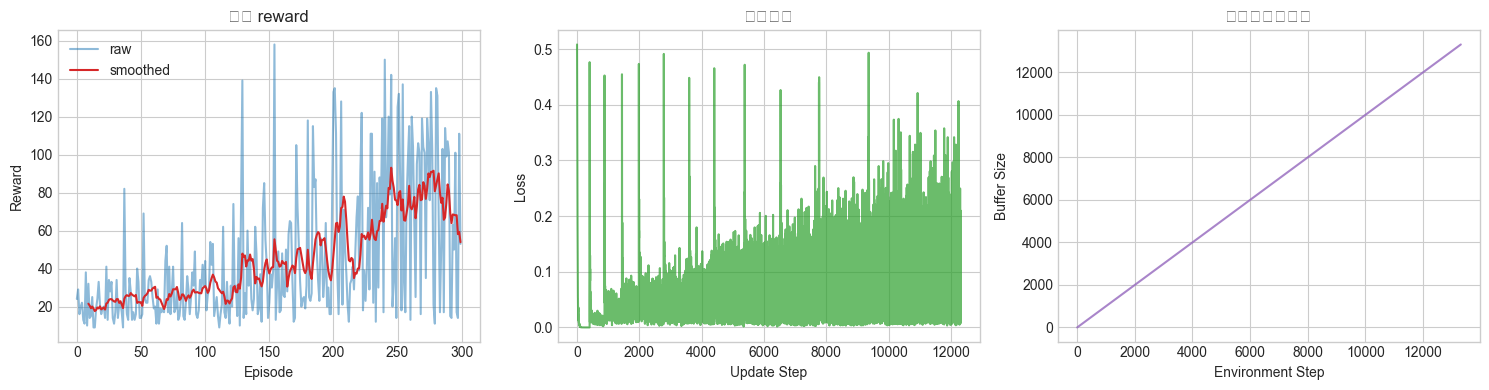

In [7]:
window = 10
smoothed_rewards = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(episode_rewards, color='#1f77b4', alpha=0.5, label='raw')
axes[0].plot(range(window - 1, len(episode_rewards)), smoothed_rewards, color='#d62728', label='smoothed')
axes[0].set_title('每轮 reward')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].legend()

axes[1].plot(loss_history, color='#2ca02c', alpha=0.7)
axes[1].set_title('训练损失')
axes[1].set_xlabel('Update Step')
axes[1].set_ylabel('Loss')

axes[2].plot(buffer_sizes, color='#9467bd', alpha=0.8)
axes[2].set_title('经验池大小变化')
axes[2].set_xlabel('Environment Step')
axes[2].set_ylabel('Buffer Size')

plt.tight_layout()
plt.show()


## 7. 用训练好的模型跑一轮看看

这里我们不渲染动画，只是让训练好的模型跑一轮，并统计它这一轮坚持了多少步。

如果模型学得不错，这个数字通常会明显高于训练早期。


In [8]:
test_env = gym.make('CartPole-v1')
test_rewards = []

q_net.eval()
with torch.no_grad():
    for episode_idx in range(5):
        state, info = test_env.reset(seed=123 + episode_idx)
        test_reward = 0.0
        for step in range(500):
            state_tensor = to_tensor(state, device).unsqueeze(0)
            action = int(torch.argmax(q_net(state_tensor), dim=1).item())
            state, reward, terminated, truncated, info = test_env.step(action)
            test_reward += reward
            if terminated or truncated:
                break
        test_rewards.append(test_reward)

print('测试 rewards:', test_rewards)
print('测试平均 reward:', round(float(np.mean(test_rewards)), 2))
test_env.close()


测试 rewards: [111.0, 95.0, 116.0, 101.0, 99.0]
测试平均 reward: 104.4


## 8. 这节课你要真正看懂什么

到这里，你已经完成了一个非常重要的跨越：

- 以前的状态是离散整数，可以查表
- 现在的状态是连续实数向量，必须靠神经网络泛化

所以 `CartPole + DQN` 的意义不是环境更炫，而是它第一次让你真正感受到：

**深度强化学习之所以需要深度网络，是因为状态空间已经不能靠表格硬记了。**


## 9. 下一课最自然学什么

学完这节后，最适合继续的方向有两个：
- `Double DQN`：解决 Q 值高估问题
- `Dueling DQN`：把状态价值和动作优势拆开学

如果按学习顺序，我最推荐你下一课先上 `Double DQN`。


In [1]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()